ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

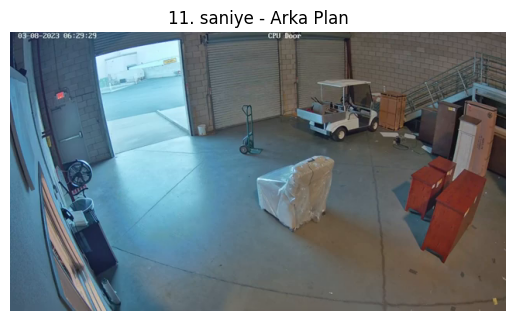

In [19]:
#Bu notebook içinde ısı haritası ilgili video arka planına yerleştirlecektir. Kısaca overlay yapılacak.

# video 12 saniye 11.saniyede hiç insan gözükmediğinden 11.saniyedeki frame i arkaplan olarak aldık.
!ffmpeg -ss 00:00:11 -i '/kaggle/input/datasets/zlemdemir/original-video-for-overlay/fabrika_video_3.mp4' -frames:v 1 /kaggle/working/arkaplan.png -y

import cv2
frame = cv2.imread('/kaggle/working/arkaplan.png')
print(f"Frame boyutu: {frame.shape}")

# 11.saniyedi frame'i görelim
import matplotlib.pyplot as plt
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title('11. saniye - Arka Plan')
plt.axis('off')
plt.show()


In [33]:
import numpy as np
from scipy.ndimage import gaussian_filter
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/zlemdemir/koordinates-for-overlay/koordinatlar_for_2_person.csv')
df = df[df['class'] == 'person']

print(f"CSV yüklendi: {len(df)} satır")

video_height, video_width = frame.shape[:2]
print(f"Frame boyutu: {video_height}x{video_width}")

heatmap = np.zeros((video_height, video_width))

x_coords = df['x'].astype(int).values
y_coords = df['y'].astype(int).values

for x, y in zip(x_coords, y_coords):
    if 0 <= x < video_width and 0 <= y < video_height:
        heatmap[y, x] += 1

heatmap_smooth = gaussian_filter(heatmap, sigma=15)
heatmap_normalized = (heatmap_smooth / heatmap_smooth.max() * 255).astype(np.uint8)

print(f"Max yoğunluk: {heatmap_smooth.max():.2f}")

CSV yüklendi: 268 satır
Frame boyutu: 360x640
Max yoğunluk: 0.03


In [34]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

heatmap_color = cm.jet(heatmap_normalized / 255.0)  
heatmap_color = (heatmap_color[:, :, :3] * 255).astype(np.uint8)  

# BGR'den RGB'ye çevir (OpenCV BGR kullandığından)
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# Overlay: arka plan %60, ısı haritası %40
overlay = cv2.addWeighted(frame_rgb, 0.6, heatmap_color, 0.5, 0)

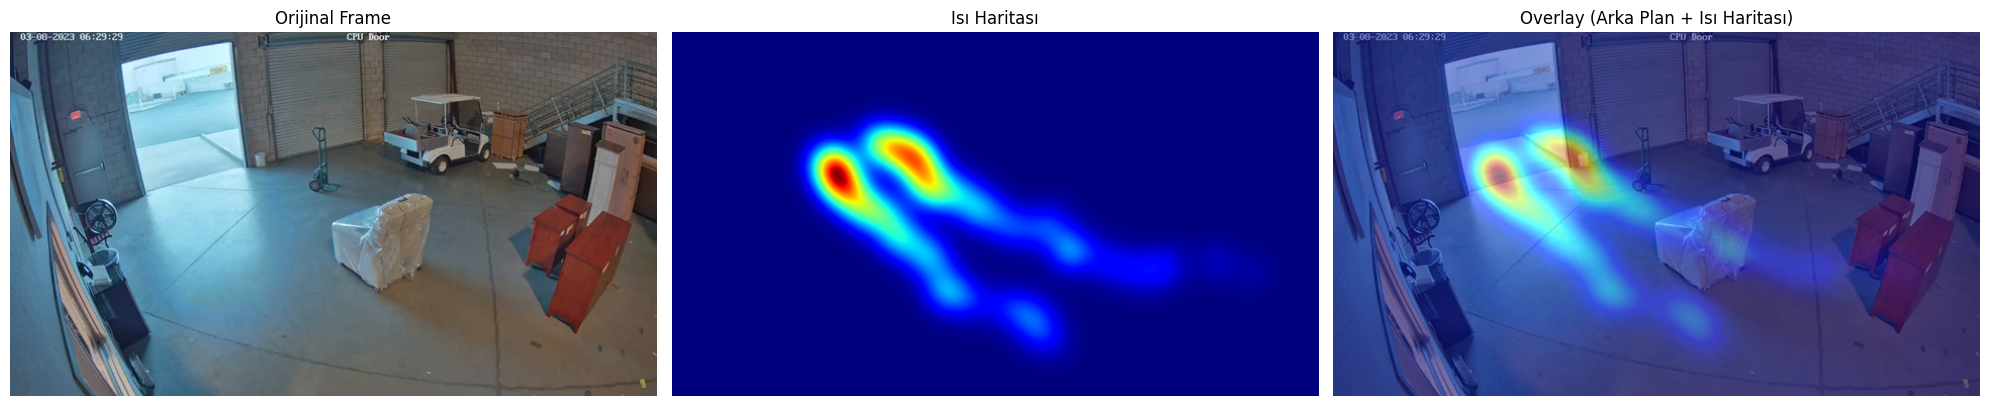

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Orijinal frame
axes[0].imshow(frame_rgb)
axes[0].set_title('Orijinal Frame')
axes[0].axis('off')

# Sadece ısı haritası
axes[1].imshow(heatmap_smooth, cmap='jet')
axes[1].set_title('Isı Haritası')
axes[1].axis('off')

# Overlay
axes[2].imshow(overlay)
axes[2].set_title('Overlay (Arka Plan + Isı Haritası)')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/overlay_sonuc.png', dpi=150, bbox_inches='tight')
plt.show()